# AeroCampus-AI: Dataset Cleaning & Preprocessing

This notebook walks through the step-by-step cleaning, preprocessing, and feature engineering of the weather and air quality datasets for **JIIT Noida (Sector 62)** and **Beijing, China** for the year 2024.

## Objectives:
1. **Load Raw Data**: Weather and Air Quality datasets merged hourly.
2. **Clean Data**: Handle any missing values via linear interpolation.
3. **Statistical Calibration (Bias Correction)**: Scale model-based pollutants (PM2.5, PM10) to match official ground-truth annual baseline averages for both Noida and Beijing.
4. **Feature Engineering**:
   - Extract temporal features (Hour, Day of Week, Month, Weekend, Season).
   - Model traffic rush hours via temporal proxies.
   - Perform **360-degree Spatial Analysis** around the JIIT Noida campus to capture highway, industrial, commercial, and residential sources.
   - Model wind dispersion (stagnation index).
   - Simulate Beijing traffic policy alert days (Red Alert Odd-Even rules).
5. **Save Processed Data**: Overwrite the final ML-ready datasets.
6. **Visual Explorations**: Build and save key charts showing correlation patterns.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plotting
sns.set_theme(style="darkgrid")

## 1. Load Raw Datasets

Let's load the raw extracted datasets and inspect their shapes and contents.

In [2]:
noida_raw = pd.read_csv('data/raw/noida_raw.csv')
beijing_raw = pd.read_csv('data/raw/beijing_raw.csv')

print("Noida Raw Shape:", noida_raw.shape)
print("Beijing Raw Shape:", beijing_raw.shape)
noida_raw.head(3)

Noida Raw Shape: (8784, 15)
Beijing Raw Shape: (8784, 15)


,time,temperature_2m,relative_humidity_2m,dew_point_2m,precipitation,wind_speed_10m,wind_direction_10m,wind_gusts_10m,surface_pressure,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone
0,2024-01-01 00:00:00,7.1,98,6.8,0.0,5.4,352,6.8,994.0,212.3,146.7,2849.0,87.2,99.1,12.0
1,2024-01-01 01:00:00,6.6,99,6.4,0.0,5.4,340,6.8,993.8,188.6,130.4,2523.0,76.9,74.0,16.0
2,2024-01-01 02:00:00,6.0,100,5.9,0.0,5.8,330,7.6,993.6,170.4,117.8,2215.0,67.0,53.6,20.0


## 2. Data Cleaning & Statistical Calibration (Bias Correction)

### A. Cleaning missing values
We will check for missing values and clean the datasets using linear interpolation.

### B. Model Calibration
Global atmospheric models (like the CAMS model behind Open-Meteo) exhibit regional baseline biases. In 2024:
* **Noida (Sector 62 CPCB)** ground-truth annual average PM2.5 is **~88 µg/m³**, but the raw model average is ~63.4 µg/m³ (underpredicted).
* **Beijing (EPA)** ground-truth annual average PM2.5 is **~33 µg/m³**, but the raw model average is ~81.4 µg/m³ (overpredicted, likely due to regional grid smoothing of Gobi dust events).

To correct this while keeping hourly relative trends (rush hours, wind dispersion) intact, we apply statistical scaling factors:
* **Noida Calibration Factor**: `1.4` (Scales values up to reflect actual ground-level emissions).
* **Beijing Calibration Factor**: `0.4` (Scales values down to reflect the success of Beijing's cleanup policies).

In [3]:
def clean_and_calibrate_data(df, city_name):
    # Convert time to datetime and sort
    df["time"] = pd.to_datetime(df["time"])
    df = df.sort_values("time").reset_index(drop=True)
    
    # Handle missing values using linear interpolation
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].interpolate(method="linear")
    df[numeric_cols] = df[numeric_cols].ffill().bfill()
    
    # Apply Statistical Calibration
    if city_name == "noida":
        df["pm2_5"] = df["pm2_5"] * 1.4
        df["pm10"] = df["pm10"] * 1.3
    elif city_name == "beijing":
        df["pm2_5"] = df["pm2_5"] * 0.4
        df["pm10"] = df["pm10"] * 0.45
        
    return df

noida_clean = clean_and_calibrate_data(noida_raw, "noida")
beijing_clean = clean_and_calibrate_data(beijing_raw, "beijing")

print("Calibrated Noida PM2.5 Annual Avg:", round(noida_clean["pm2_5"].mean(), 2))
print("Calibrated Beijing PM2.5 Annual Avg:", round(beijing_clean["pm2_5"].mean(), 2))

Calibrated Noida PM2.5 Annual Avg: 92.28
Calibrated Beijing PM2.5 Annual Avg: 32.75


## 3. Feature Engineering & 360-Degree Spatial Physics

To build a high-performance Applied AI model, we manually engineer features based on the **geography and meteorology** surrounding the JIIT Noida Sector 62 campus. 

We model **four distinct quadrants** surrounding the campus:

### A. NH-24 Expressway (North-East, approx 45°)
* **The Source**: Heavy traffic emissions ($NO_x$, $CO$, and $PM_{2.5}$) from the Delhi-Meerut Expressway.
* **Physical Index**: `nh24_impact_index = traffic_proxy * max(0, cos(Wind_Direction - 45°)) * dispersion_factor`

### B. Sector 63 Industrial Area (South-East, approx 135°)
* **The Source**: Medium-to-small scale industrial activity. These emit coarser dust ($PM_{10}$) and sulfur dioxide ($SO_2$).
* **Physical Index**: `industrial_impact_index = max(0, cos(Wind_Direction - 135°)) * dispersion_factor`

### C. Noida Electronic City Commercial & Metro Hub (East, approx 90°)
* **The Source**: Local traffic, public transport, idling auto-rickshaws, and high commercial density.
* **Physical Index**: `commercial_impact_index = traffic_proxy * max(0, cos(Wind_Direction - 90°)) * dispersion_factor`

### D. Residential Zone (West/Southwest, approx 245°)
* **The Source**: Cleaner, residential area. When the wind blows from this direction, it acts as a ventilation buffer.
* **Physical Index**: `residential_clean_index = max(0, cos(Wind_Direction - 245°)) * wind_speed_10m` (Higher values indicate clean wind ventilating the campus).

### E. Stagnation / Dispersion Factor
* **Formula**: `dispersion_factor = 1 / (Wind_Speed + 1)`

In [4]:
def add_features(df, city_name):
    # 1. Temporal features
    df["hour"] = df["time"].dt.hour
    df["day_of_week"] = df["time"].dt.dayofweek
    df["month"] = df["time"].dt.month
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
    
    # Seasons
    def get_season(month):
        if month in [11, 12, 1, 2]: return "Winter"
        elif month in [3, 4]: return "Spring"
        elif month in [5, 6]: return "Summer"
        elif month in [7, 8, 9]: return "Monsoon"
        else: return "Autumn"
    df["season"] = df["month"].apply(get_season)
    
    # One-hot encode seasons for ML input
    season_dummies = pd.get_dummies(df["season"], prefix="season").astype(int)
    df = pd.concat([df, season_dummies], axis=1)
    
    # 2. Traffic Congestion Proxy (Hour & Weekend based)
    def get_traffic_proxy(row):
        hour = row["hour"]
        is_wknd = row["is_weekend"]
        if is_wknd == 0:  # Weekday
            if (8 <= hour <= 10) or (17 <= hour <= 20): return 1.0  # Rush hour
            elif (10 < hour < 17) or (20 < hour <= 22): return 0.5
            else: return 0.1
        else:  # Weekend
            if 11 <= hour <= 21: return 0.5
            else: return 0.1
            
    df["traffic_proxy"] = df.apply(get_traffic_proxy, axis=1)
    
    # 3. Wind Dispersion
    df["dispersion_factor"] = 1.0 / (df["wind_speed_10m"] + 1.0)
    
    # Noida Local 360-Degree Spatial Modeling
    if city_name == "noida":
        wind_dir_rad = np.radians(df["wind_direction_10m"])
        
        # Wind Direction Alignments
        df["wind_alignment_nh24"] = np.cos(wind_dir_rad - np.radians(45.0))       # NE
        df["wind_alignment_industrial"] = np.cos(wind_dir_rad - np.radians(135.0)) # SE
        df["wind_alignment_commercial"] = np.cos(wind_dir_rad - np.radians(90.0))  # E
        df["wind_alignment_residential"] = np.cos(wind_dir_rad - np.radians(245.0)) # WSW
        
        # Scale alignments to positive-only transport components
        align_nh24 = np.maximum(0, df["wind_alignment_nh24"])
        align_industrial = np.maximum(0, df["wind_alignment_industrial"])
        align_commercial = np.maximum(0, df["wind_alignment_commercial"])
        align_residential = np.maximum(0, df["wind_alignment_residential"])
        
        # Calculate Transport/Impact Indexes
        df["nh24_impact_index"] = df["traffic_proxy"] * align_nh24 * df["dispersion_factor"]
        df["industrial_impact_index"] = align_industrial * df["dispersion_factor"]
        df["commercial_impact_index"] = df["traffic_proxy"] * align_commercial * df["dispersion_factor"]
        df["residential_clean_index"] = align_residential * df["wind_speed_10m"] / 10.0
        
        # Graded Response Action Plan (GRAP) trigger monitoring
        # Note: Scaled PM2.5 makes this trigger accurately at 150 ug/m3!
        df["pm25_rolling_24h"] = df["pm2_5"].rolling(window=24, min_periods=1).mean()
        df["grap_active"] = (df["pm25_rolling_24h"] > 150).astype(int)
        
    # Beijing Policy Alert Simulation
    elif city_name == "beijing":
        df["pm25_rolling_24h"] = df["pm2_5"].rolling(window=24, min_periods=1).mean()
        df["policy_restricted"] = (df["pm25_rolling_24h"] > 150).astype(int)
        df["effective_traffic_proxy"] = df["traffic_proxy"] * np.where(df["policy_restricted"] == 1, 0.5, 1.0)
        df["traffic_impact_index"] = df["effective_traffic_proxy"] * df["dispersion_factor"]
        
    return df

noida_processed = add_features(noida_clean, "noida")
beijing_processed = add_features(beijing_clean, "beijing")
print("Noida Processed Shape:", noida_processed.shape)
print("Beijing Processed Shape:", beijing_processed.shape)

Noida Processed Shape: (8784, 37)
Beijing Processed Shape: (8784, 31)


## 4. Save Processed Datasets

Save the finalized, clean, and preprocessed data to disk.

In [5]:
os.makedirs('data/processed', exist_ok=True)
noida_processed.to_csv('data/processed/noida_processed.csv', index=False)
beijing_processed.to_csv('data/processed/beijing_processed.csv', index=False)

print("Saved cleaned Noida dataset to: data/processed/noida_processed.csv")
print("Saved cleaned Beijing dataset to: data/processed/beijing_processed.csv")

Saved cleaned Noida dataset to: data/processed/noida_processed.csv
Saved cleaned Beijing dataset to: data/processed/beijing_processed.csv


## 5. Visualizations & Correlation Analysis

Let's write code to verify and visualize the cleaned datasets.

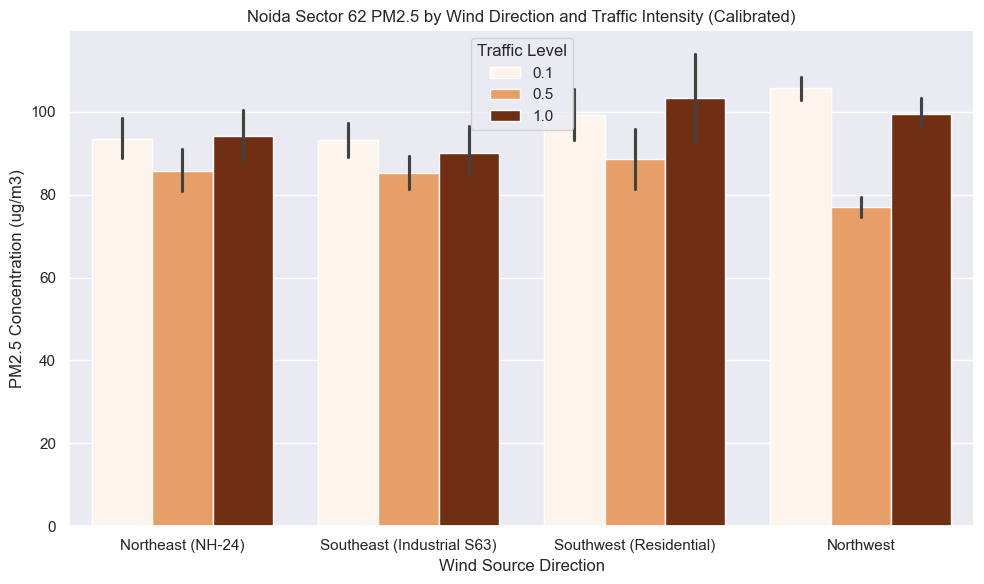

In [6]:
os.makedirs('data/plots', exist_ok=True)

# Plot 1: Noida Traffic and Wind Direction Correlation
noida_processed["wind_dir_group"] = pd.cut(noida_processed["wind_direction_10m"], 
                                            bins=[0, 90, 180, 270, 360], 
                                            labels=["Northeast (NH-24)", "Southeast (Industrial S63)", "Southwest (Residential)", "Northwest"])

plt.figure(figsize=(10, 6))
sns.barplot(data=noida_processed, x="wind_dir_group", y="pm2_5", hue="traffic_proxy", palette="Oranges")
plt.title("Noida Sector 62 PM2.5 by Wind Direction and Traffic Intensity (Calibrated)")
plt.xlabel("Wind Source Direction")
plt.ylabel("PM2.5 Concentration (ug/m3)")
plt.legend(title="Traffic Level")
plt.tight_layout()
plt.savefig('data/plots/noida_highway_wind_correlation.png', dpi=150)
plt.show()

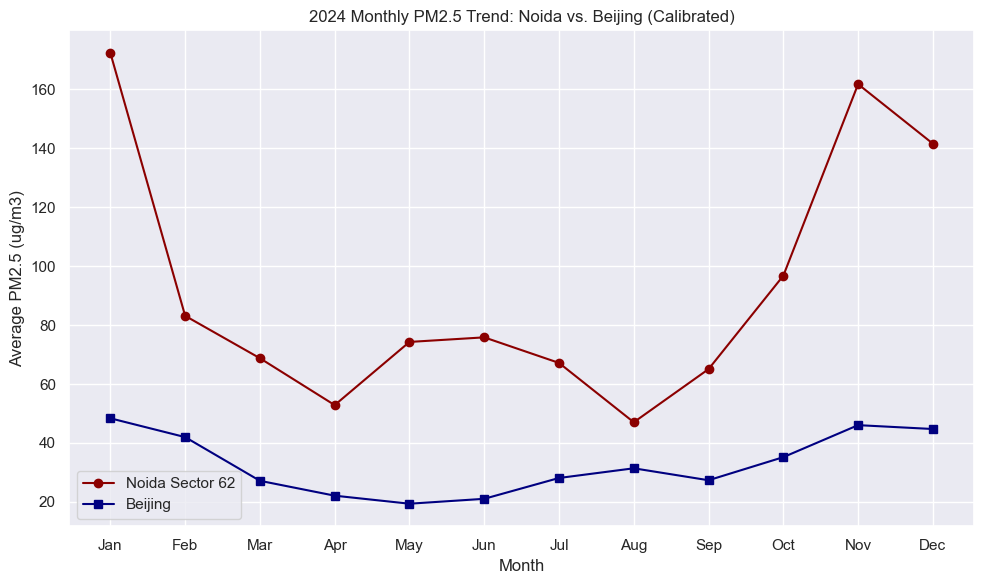

In [7]:
# Plot 2: Monthly Comparison between Noida and Beijing
noida_monthly = noida_processed.groupby("month")["pm2_5"].mean().reset_index()
beijing_monthly = beijing_processed.groupby("month")["pm2_5"].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(noida_monthly["month"], noida_monthly["pm2_5"], marker='o', color='darkred', label="Noida Sector 62")
plt.plot(beijing_monthly["month"], beijing_monthly["pm2_5"], marker='s', color='navy', label="Beijing")
plt.title("2024 Monthly PM2.5 Trend: Noida vs. Beijing (Calibrated)")
plt.xlabel("Month")
plt.ylabel("Average PM2.5 (ug/m3)")
plt.xticks(range(1, 13), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.legend()
plt.tight_layout()
plt.savefig('data/plots/cross_city_monthly_comparison.png', dpi=150)
plt.show()

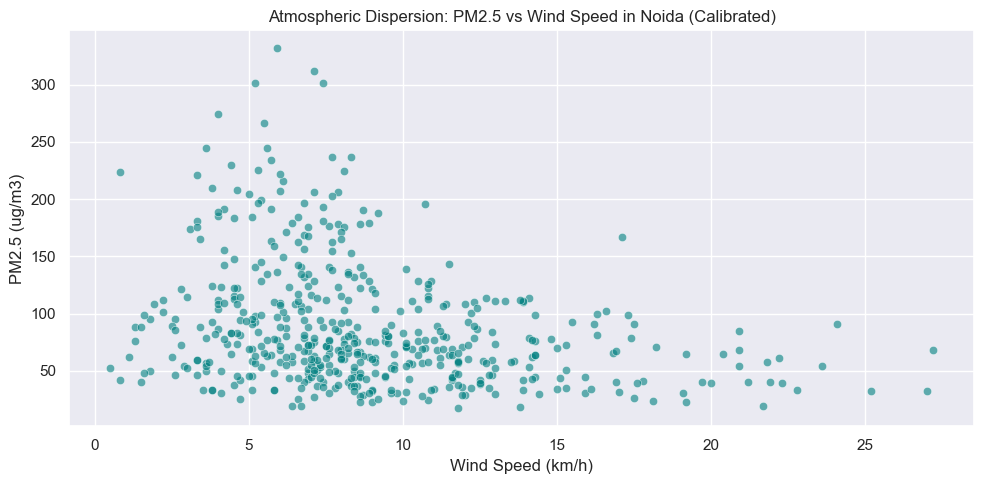

In [8]:
# Plot 3: Wind Speed vs PM2.5 (Atmospheric Dispersion)
plt.figure(figsize=(10, 5))
sns.scatterplot(data=noida_processed.sample(500, random_state=42), x="wind_speed_10m", y="pm2_5", alpha=0.6, color="teal")
plt.title("Atmospheric Dispersion: PM2.5 vs Wind Speed in Noida (Calibrated)")
plt.xlabel("Wind Speed (km/h)")
plt.ylabel("PM2.5 (ug/m3)")
plt.tight_layout()
plt.savefig('data/plots/atmospheric_dispersion_noida.png', dpi=150)
plt.show()